# 📈 Monthly Revenue Forecasting (SARIMA)

This notebook builds a **planning-grade monthly revenue forecasting model** using validated
PostgreSQL KPI views. It is designed for executive reporting and scenario planning.

**Key deliverables**
- Trend + seasonality analysis
- Leakage-free backtesting (last 6 months)
- Model evaluation (MAE, RMSE, sMAPE) + baseline comparison
- 6-month forecast with 95% confidence intervals
- Optional: write forecast outputs back to PostgreSQL for Power BI

---

## 1) Objective & Business Context

**Business question:**  
> “What will monthly revenue look like over the next 6 months?”

This forecast supports:
- revenue planning and target setting,
- staffing and inventory planning,
- executive scenario analysis using confidence intervals.

The model is trained on **monthly revenue** aggregated in PostgreSQL (single source of truth).

## Imports & Settings

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sqlalchemy import create_engine

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---- Notebook display preferences ----
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Optional: keep plots consistent
plt.rcParams["figure.figsize"] = (12, 4)

# Reduce noisy warnings (we will still explain the key one in markdown)
warnings.filterwarnings("ignore", category=UserWarning)

## 2) Configuration

We keep model settings and constants in one place to make the notebook production-like.

In [2]:
# ---- Forecasting configuration ----
FORECAST_HORIZON = 6
SEASONAL_PERIOD = 12

SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL = (0, 1, 1, SEASONAL_PERIOD)  # simpler seasonal structure

# ---- Helpers ----
def smape(y_true, y_pred) -> float:
    """
    Symmetric MAPE (sMAPE) is robust when values are near zero.
    Returns percentage error.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100)

def format_currency_axis(ax):
    """Format y-axis as currency-like values with commas and no decimals."""
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.grid(True, linestyle="--", alpha=0.3)

def plot_series(series: pd.Series, title: str, ylabel: str = "Revenue"):
    """Quick clean line plot for a time series."""
    ax = series.plot(title=title)
    ax.set_xlabel("month")
    ax.set_ylabel(ylabel)
    format_currency_axis(ax)
    plt.tight_layout()
    plt.show()

## 3) Data Source (PostgreSQL KPI View)

We pull data from:

- `public.vw_monthly_sales`
- Columns: `month`, `monthly_sales`

This ensures:
- consistent KPI logic across SQL + Power BI + forecasting,
- no duplication of business definitions in notebooks.

In [3]:
engine = create_engine(
    f"postgresql://{os.getenv('PG_USER')}:{os.getenv('PG_PASSWORD')}"
    f"@{os.getenv('PG_HOST')}:{os.getenv('PG_PORT')}/{os.getenv('PG_DB')}"
)

query = """
SELECT month, monthly_sales
FROM public.vw_monthly_sales
ORDER BY month;
"""

ts_df = pd.read_sql(query, engine)
ts_df.head()

,month,monthly_sales
0,2011-01-01,"98,902.00"
1,2011-02-01,"91,152.00"
2,2011-03-01,"145,726.00"
3,2011-04-01,"116,927.00"
4,2011-05-01,"146,762.00"


## 4) Time Series Preparation & Validation

We enforce:
- proper datetime index
- monthly frequency (`MS` = Month Start)
- no missing months

This step is critical for reliable seasonal modeling.

In [4]:
ts_df["month"] = pd.to_datetime(ts_df["month"])
ts_df = ts_df.set_index("month").sort_index()

# Enforce monthly frequency at month start (MS)
ts_df = ts_df.asfreq("MS")

# Data quality checks
print("Missing months:", ts_df["monthly_sales"].isna().sum())
print("Date range:", ts_df.index.min().date(), "to", ts_df.index.max().date())
print("Observations:", ts_df.shape[0])

ts_df.describe()

Missing months: 0
Date range: 2011-01-01 to 2014-12-01
Observations: 48


,monthly_sales
count,48.00
mean,"263,393.85"
std,"113,887.33"
min,"91,152.00"
25%,"175,188.00"
50%,"254,561.50"
75%,"328,353.50"
max,"555,312.00"


## 5) Exploratory Time Series Analysis

We inspect:
- overall trend direction
- volatility / spikes
- evidence of seasonality

We also run a classical seasonal decomposition (additive).

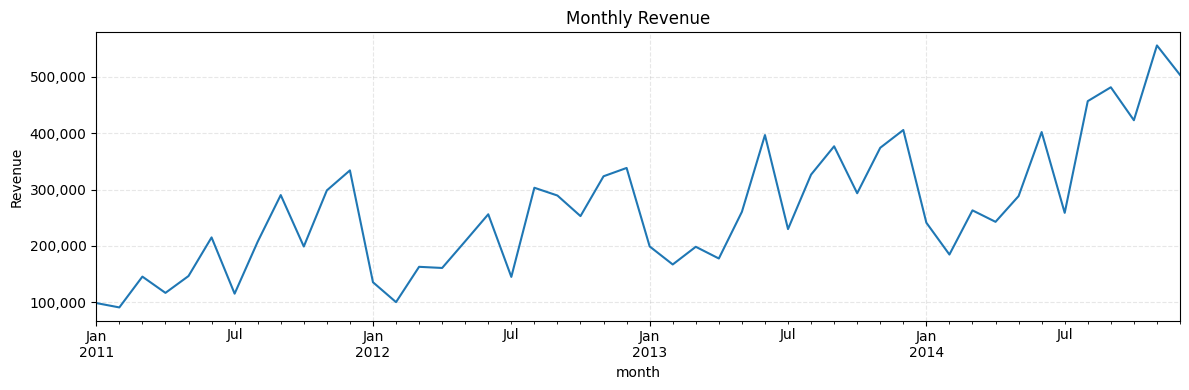

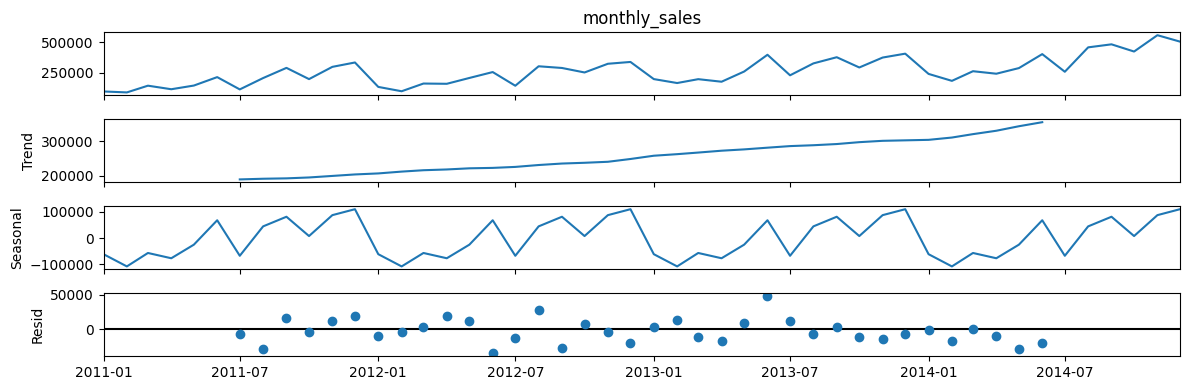

In [5]:
plot_series(ts_df["monthly_sales"], title="Monthly Revenue")

# Seasonal decomposition (requires a defined seasonal period)
decomp = seasonal_decompose(ts_df["monthly_sales"], model="additive", period=SEASONAL_PERIOD)
decomp.plot()
plt.tight_layout()
plt.show()

## 6) Stationarity Diagnostics (ADF Test)

Most ARIMA-family models require stationarity (or stationarity after differencing).
We use the Augmented Dickey-Fuller test as a quick diagnostic.

Interpretation:
- **p-value > 0.05** suggests the series is non-stationary → differencing is required.

In [6]:
adf_stat, p_value, *_ = adfuller(ts_df["monthly_sales"])

print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")

ADF Statistic: 0.6184
p-value: 0.9881


## 7) Modeling Strategy

We use a **Seasonal ARIMA (SARIMA)** model:

- Non-seasonal: (p,d,q) = (1,1,1)
- Seasonal: (P,D,Q,s) = (0,1,1,12)

Why this specification?
- `d=1` addresses non-stationarity / growth trend
- `D=1, s=12` captures annual seasonality
- The seasonal component is intentionally simple to reduce overfitting risk,
  given limited history (48 months = ~4 seasonal cycles)

**Note on warnings:**  
Statsmodels may warn about “too few observations” for seasonal parameter initialization.
This is expected with short seasonal series. The model still converges and is suitable
for planning-grade forecasts.

In [7]:
train = ts_df.iloc[:-FORECAST_HORIZON].copy()
test = ts_df.iloc[-FORECAST_HORIZON:].copy()

print("Train period:", train.index.min().date(), "to", train.index.max().date(), "| n =", len(train))
print("Test period: ", test.index.min().date(), "to", test.index.max().date(), "| n =", len(test))

Train period: 2011-01-01 to 2014-06-01 | n = 42
Test period:  2014-07-01 to 2014-12-01 | n = 6


## 8) Backtest Evaluation (Holdout: last 6 months)

We perform a leakage-free evaluation:
- Train on the first 42 months
- Forecast the last 6 months
- Compare predictions vs actuals

We also include a baseline:
✅ **Seasonal Naive** (forecast = same month last year)

A model must beat the baseline to be considered useful.

### Baseline: Seasonal Naive

In [8]:
# --- Baseline: Seasonal Naive (same month last year) ---
baseline_pred = ts_df["monthly_sales"].shift(SEASONAL_PERIOD).reindex(test.index)

# Ensure no missing baseline values (should be 0 NaNs with 48 months of history)
assert baseline_pred.isna().sum() == 0, "Baseline contains NaNs - check monthly index/frequency."

baseline_mae = mean_absolute_error(test["monthly_sales"], baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(test["monthly_sales"], baseline_pred))
baseline_smape = smape(test["monthly_sales"], baseline_pred)

pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "sMAPE (%)"],
        "baseline_seasonal_naive": [baseline_mae, baseline_rmse, baseline_smape],
    }
)

,metric,baseline_seasonal_naive
0,MAE,"111,972.67"
1,RMSE,"121,002.01"
2,sMAPE (%),27.67


### Fit SARIMA on train

In [9]:
model = SARIMAX(
    train["monthly_sales"],
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      monthly_sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -177.182
Date:                            Sun, 01 Feb 2026   AIC                            362.363
Time:                                    11:29:13   BIC                            365.195
Sample:                                01-01-2011   HQIC                           362.333
                                     - 06-01-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1952      0.667      0.293      0.770      -1.112       1.502
ma.L1         -0.8481      0.120   

### Backtest Forecast + Metrics

In [10]:
# Forecast exactly the test horizon
fc = results.get_forecast(steps=len(test))
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

# Align indices explicitly (best practice)
fc_mean.index = test.index
fc_ci.index = test.index

# Evaluate
sarima_mae = mean_absolute_error(test["monthly_sales"], fc_mean)
sarima_rmse = np.sqrt(mean_squared_error(test["monthly_sales"], fc_mean))
sarima_smape = smape(test["monthly_sales"], fc_mean)

comparison = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "sMAPE (%)"],
        "baseline_seasonal_naive": [baseline_mae, baseline_rmse, baseline_smape],
        "sarima": [sarima_mae, sarima_rmse, sarima_smape],
    }
)

comparison

,metric,baseline_seasonal_naive,sarima
0,MAE,"111,972.67","70,220.47"
1,RMSE,"121,002.01","79,584.77"
2,sMAPE (%),27.67,16.09


### Backtest Plot (Forecast vs Actual)

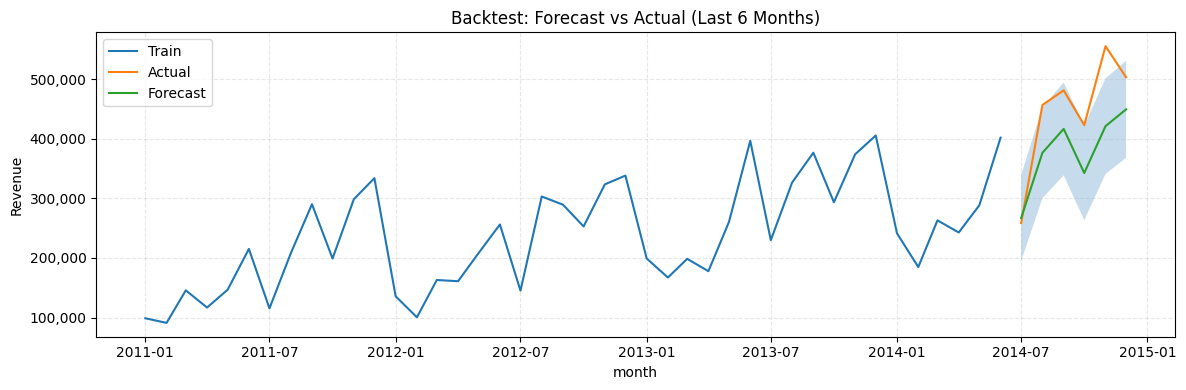

In [11]:
plt.figure(figsize=(12,4))
plt.plot(train.index, train["monthly_sales"], label="Train")
plt.plot(test.index, test["monthly_sales"], label="Actual")
plt.plot(test.index, fc_mean, label="Forecast")

plt.fill_between(
    test.index,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    alpha=0.25
)

plt.title("Backtest: Forecast vs Actual (Last 6 Months)")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.legend()

ax = plt.gca()
format_currency_axis(ax)
plt.tight_layout()
plt.show()

## 9) Final Model Training & 6-Month Forecast

After validating on the holdout period, we refit the chosen SARIMA model
on the full history and produce a 6-month revenue forecast with 95% confidence bounds.

In [ ]:
final_model = SARIMAX(
    ts_df["monthly_sales"],
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

final_results = final_model.fit(disp=False)

future = final_results.get_forecast(steps=FORECAST_HORIZON)
future_df = future.summary_frame()

future_df

monthly_sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2015-01-01,"338,247.75","43,530.45","252,929.63","423,565.86"
2015-02-01,"284,715.02","50,107.35","186,506.41","382,923.62"
2015-03-01,"350,395.56","52,485.64","247,525.59","453,265.54"
2015-04-01,"329,966.79","53,646.81","224,820.97","435,112.61"
2015-05-01,"381,991.13","54,376.83","275,414.50","488,567.76"
2015-06-01,"495,032.30","54,931.82","387,367.92","602,696.68"


### Plot Future Forecast (Historical + Forecast + CI)

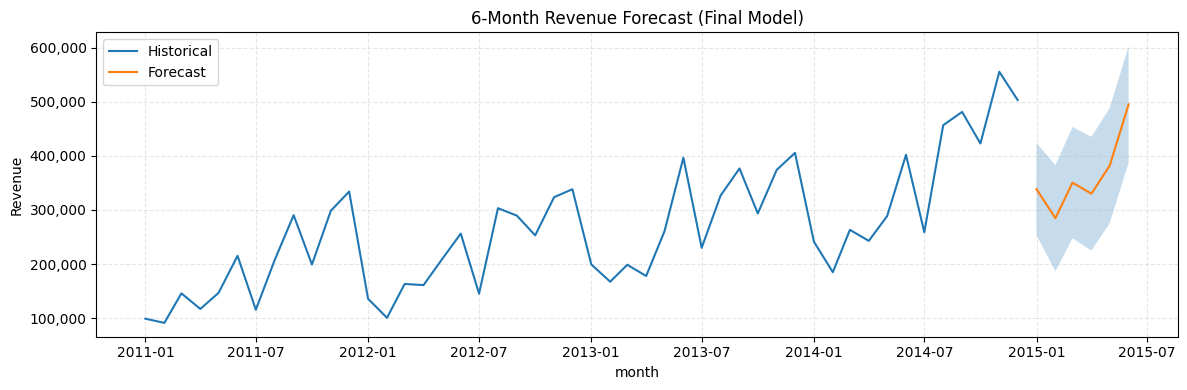

In [13]:
plt.figure(figsize=(12,4))
plt.plot(ts_df.index, ts_df["monthly_sales"], label="Historical")
plt.plot(future_df.index, future_df["mean"], label="Forecast")

plt.fill_between(
    future_df.index,
    future_df["mean_ci_lower"],
    future_df["mean_ci_upper"],
    alpha=0.25
)

plt.title("6-Month Revenue Forecast (Final Model)")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.legend()

ax = plt.gca()
format_currency_axis(ax)
plt.tight_layout()
plt.show()

## 10) Business Interpretation & Recommendations

**What the model indicates**
- Revenue shows a consistent upward trend with clear seasonal variation.
- Forecast intervals widen over time, reflecting increasing uncertainty.

**How to use the forecast**
- Use the forecast mean as the baseline plan.
- Use the upper confidence bound for optimistic scenarios.
- Use the lower bound for risk-aware planning.
- Re-run monthly as new data becomes available (rolling updates).

This model is intended for **executive planning and scenario analysis**, not high-frequency demand prediction.

## 12) Export Artifacts

We export:
- `data/processed/monthly_forecast.csv` (future forecast table)
- `data/processed/backtest_forecast.csv` (backtest forecast vs actual)

This supports reproducibility and Power BI integration.

In [ ]:
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

# Backtest outputs
backtest_out = pd.DataFrame(
    {
        "month": test.index,
        "actual_sales": test["monthly_sales"].values,
        "forecast_sales": fc_mean.values,
        "ci_lower": fc_ci.iloc[:, 0].values,
        "ci_upper": fc_ci.iloc[:, 1].values,
        "run_type": "backtest",
    }
)

# Future outputs
future_out = pd.DataFrame(
    {
        "month": future_df.index,
        "actual_sales": np.nan,
        "forecast_sales": future_df["mean"].values,
        "ci_lower": future_df["mean_ci_lower"].values,
        "ci_upper": future_df["mean_ci_upper"].values,
        "run_type": "future",
    }
)

backtest_out.to_csv(out_dir / "backtest_forecast.csv", index=False)
future_out.to_csv(out_dir / "monthly_forecast.csv", index=False)

print("Saved:")
print("-", out_dir / "backtest_forecast.csv")
print("-", out_dir / "monthly_forecast.csv")

Saved:
- ..\data\processed\backtest_forecast.csv
- ..\data\processed\monthly_forecast.csv


## Write to Postgres for Power BI

In [ ]:
# Combine into one table for BI
forecast_all = pd.concat([backtest_out, future_out], ignore_index=True)

# Write a single table Power BI can read
forecast_all.to_sql(
    "monthly_sales_forecast",
    engine,
    schema="public",
    if_exists="replace",
    index=False
)

print("Wrote table: public.monthly_sales_forecast")
forecast_all.head()

Wrote table: public.monthly_sales_forecast


,month,actual_sales,forecast_sales,ci_lower,ci_upper,run_type
0,2014-07-01,"258,718.00","267,073.19","195,045.77","339,100.61",backtest
1,2014-08-01,"456,633.00","376,497.16","300,253.89","452,740.44",backtest
2,2014-09-01,"481,186.00","416,524.49","338,657.21","494,391.77",backtest
3,2014-10-01,"422,785.00","342,579.59","263,458.90","421,700.28",backtest
4,2014-11-01,"555,312.00","421,133.56","340,839.37","501,427.76",backtest
